# Chart: Vector Image Compression


[![View on GitHub](https://img.shields.io/badge/GitHub-181717?logo=github&logoColor=white)](https://github.com/bu-cds-omds/dx601-examples/blob/main/week13/chart_vector_image_compression.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bu-cds-omds/dx601-examples/blob/main/week13/chart_vector_image_compression.ipynb)



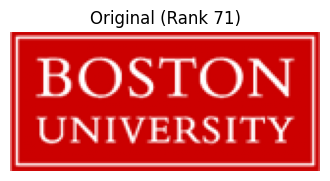

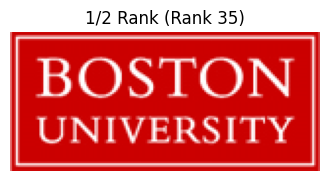

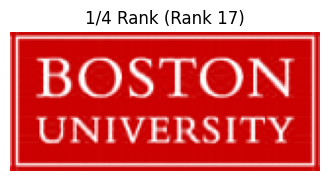

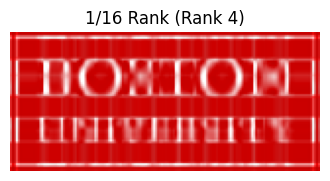

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

# 1. Load the image
url = "https://www.bu.edu/brand/files/2019/06/master_logo.gif"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')
img_array = np.array(img) / 255.0

rows, cols, channels = img_array.shape
max_rank = min(rows, cols)

# 2. Compute SVD once for each channel
svds = [np.linalg.svd(img_array[:, :, i], full_matrices=False) for i in range(channels)]

def get_approximation(k):
    reconstructed = np.zeros_like(img_array)
    for i in range(channels):
        u, s, vh = svds[i]
        # Keep only top k singular values
        s_k = np.diag(s[:k])
        u_k = u[:, :k]
        vh_k = vh[:k, :]
        reconstructed[:, :, i] = np.clip(u_k @ s_k @ vh_k, 0, 1)
    return reconstructed

# 3. Define the ranks to show
ranks = {
    "Original": max_rank,
    "1/2 Rank": max_rank // 2,
    "1/4 Rank": max_rank // 4,
    "1/16 Rank": max_rank // 16
}

# 4. Display images in separate plots
for label, k in ranks.items():
    plt.figure(figsize=(4, 3))
    if label == "Original":
        plt.imshow(img_array)
    else:
        approx_img = get_approximation(k)
        plt.imshow(approx_img)
    plt.title(f"{label} (Rank {k})")
    plt.axis('off')
    plt.show()